# Catastrophic Forgetting in Neural Networks

When a neural network is trained **sequentially** on multiple tasks, it tends
to *forget* earlier tasks as it learns new ones. This is **catastrophic forgetting**,
the central challenge that continual learning methods (EWC, SI, KD, …) try to solve.

## What we will do

1. **Task A** — Train a small CNN on **MNIST** (handwritten digits).
2. **Task B** — Continue training the **same model** on **Fashion-MNIST** (clothing items).
3. Re-evaluate on Task A and observe the accuracy drop.
4. Visualise the loss landscape and training trajectory to understand *why* it happens.


## 0. Setup for Google Colab (Run this first)

In [ ]:
# Clone repo (brings in pyproject.toml + src/cl)
!git clone https://github.com/SaptarshiSarkar12/continual-learning.git
# Move into repo root
%cd continual-learning
# Install 'cl' package + dev dependencies
!pip install '.[dev]'

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from cl import (
    SimpleCNN,
    evaluate,
    get_device,
    get_fashion_mnist,
    get_mnist,
    train_and_log,
    compute_loss_landscape,
    plot_accuracy_timeline,
    plot_loss_landscape,
    plot_loss_timeline,
    plot_trajectory_overlay,
)

device = get_device()
print(f"Using device: {device}")

Using device: cuda


### Configuration

Feel free to lower `EPOCHS_A` / `EPOCHS_B` (e.g. to 10) for a faster run if you are on CPU.

In [2]:
EPOCHS_A = 200   # epochs for Task A (MNIST)
EPOCHS_B = 200   # epochs for Task B (Fashion-MNIST)
BATCH_SIZE = 128

## 2. Load data

Task A uses the full MNIST dataset; Task B uses Fashion-MNIST. Both are 28×28 grayscale with 10 classes,
so the same model architecture works for both.


In [3]:
trainA = DataLoader(get_mnist(train=True), batch_size=BATCH_SIZE, shuffle=True)
testA  = DataLoader(get_mnist(train=False), batch_size=256)

trainB = DataLoader(get_fashion_mnist(train=True), batch_size=BATCH_SIZE, shuffle=True)
testB  = DataLoader(get_fashion_mnist(train=False), batch_size=256)

print(f"Task A (MNIST)         - train: {len(trainA.dataset):,}  test: {len(testA.dataset):,}")
print(f"Task B (Fashion-MNIST) - train: {len(trainB.dataset):,}  test: {len(testB.dataset):,}")

100.0%
100.0%
100.0%
100.0%

Task A (MNIST)         - train: 60,000  test: 10,000
Task B (Fashion-MNIST) - train: 60,000  test: 10,000


## 3. Create the model

A small CNN — fast to train, powerful enough for both MNIST and Fashion-MNIST.


In [4]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Train on Task A (MNIST)

Train to near-perfect accuracy on handwritten digits.


In [5]:
snapshots = []
accA, lossA, _ = train_and_log(model, trainA, optimizer, criterion,
                               EPOCHS_A, snapshots=snapshots)
accA_before = evaluate(model, testA)
print(f"\nTask A (MNIST) test accuracy: {accA_before:.3f}")


Task A (MNIST) test accuracy: 0.992


### Loss landscape after Task A

The model sits in a good minimum for MNIST — low loss in the centre.


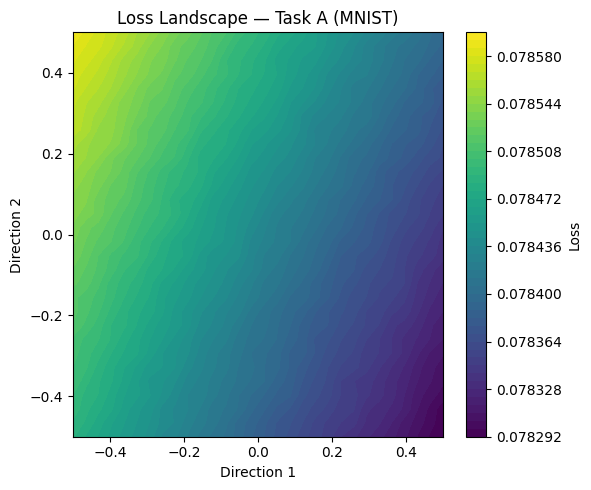

In [6]:
landscape_A = compute_loss_landscape(model, criterion, testA)
plot_loss_landscape(landscape_A, title="Loss Landscape — Task A (MNIST)", cmap="viridis")
plt.show()

## 5. Train on Task B (Fashion-MNIST)

Continue training the **same model** on Fashion-MNIST.
The optimizer updates the same weights — nothing protects what was learned for MNIST.


In [7]:
accB, lossB, accA_during_B = train_and_log(model, trainB, optimizer, criterion,
                                           EPOCHS_B, snapshots=snapshots,
                                           eval_loader=testA)
accB_final = evaluate(model, testB)
print(f"\nTask B (Fashion-MNIST) test accuracy: {accB_final:.3f}")


Task B (Fashion-MNIST) test accuracy: 0.911


## 6. The forgetting — re-evaluate Task A

How much MNIST accuracy dropped after Fashion-MNIST training?


In [8]:
accA_after = evaluate(model, testA)

print(f"Task A (MNIST) accuracy BEFORE Task B: {accA_before:.3f}")
print(f"Task A (MNIST) accuracy AFTER  Task B: {accA_after:.3f}")
print(f"\nForgetting: {accA_before - accA_after:.3f}")

Task A (MNIST) accuracy BEFORE Task B: 0.992
Task A (MNIST) accuracy AFTER  Task B: 0.339

Forgetting: 0.653


### Loss landscape after Task B


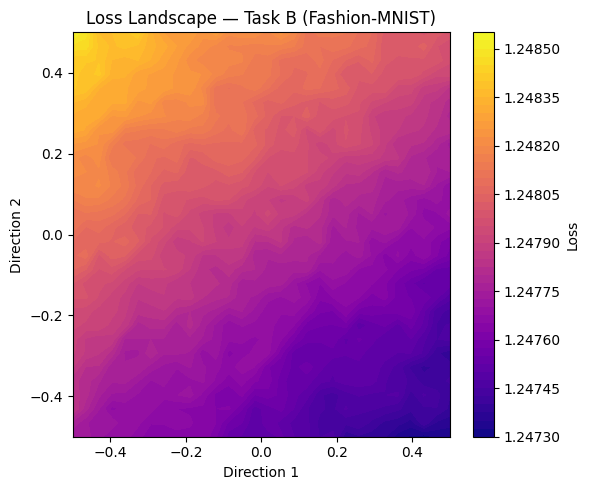

In [9]:
landscape_B = compute_loss_landscape(model, criterion, testB)
plot_loss_landscape(landscape_B, title="Loss Landscape — Task B (Fashion-MNIST)", cmap="plasma")
plt.show()

## 7. Accuracy and loss timelines

The red **"Task A test acc (during B)"** line shows MNIST accuracy plummeting
as the model trains on Fashion-MNIST — catastrophic forgetting in real time.


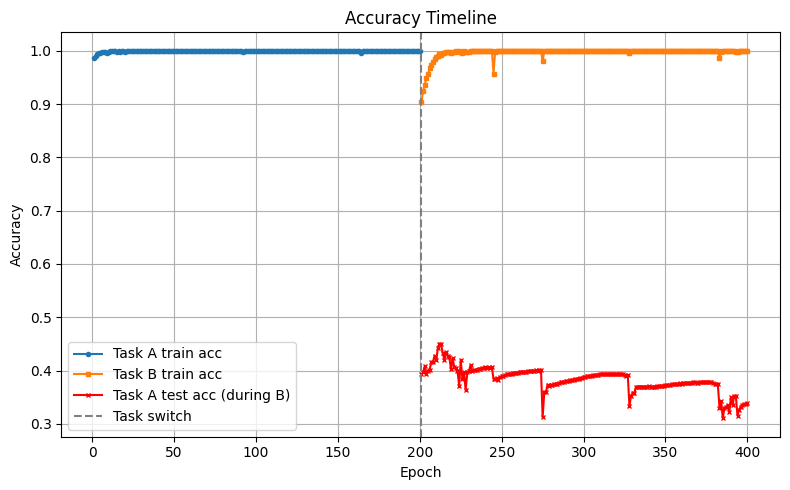

In [10]:
plot_accuracy_timeline(accA, accB, EPOCHS_A, EPOCHS_B, acc_a_during_b=accA_during_B)
plt.show()

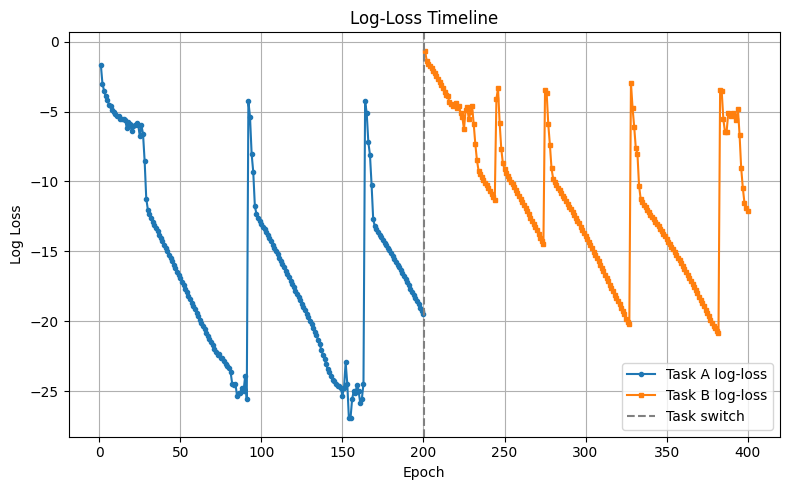

In [11]:
plot_loss_timeline(lossA, lossB, EPOCHS_A, EPOCHS_B)
plt.show()

## 8. Training trajectory on Task A's landscape

The white dashed line shows how the weights **moved away** from MNIST's
minimum during Fashion-MNIST training — the geometric picture of catastrophic forgetting.


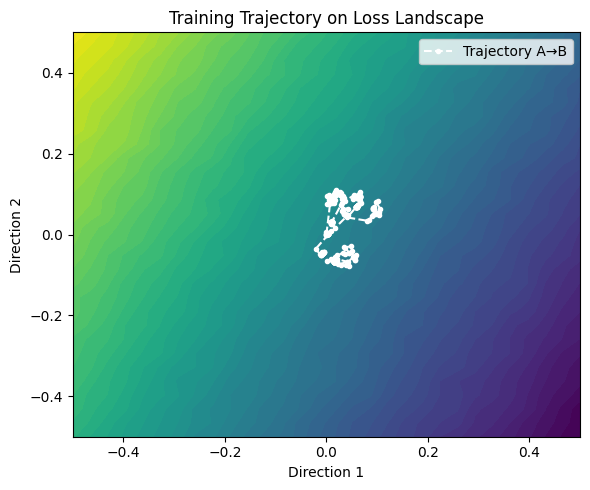

In [12]:
plot_trajectory_overlay(snapshots, landscape_A)
plt.show()

## Summary

| Metric                                | Value          |
|---------------------------------------|----------------|
| Task A (MNIST) accuracy before Task B | 0.992          |
| Task A (MNIST) accuracy after Task B  | 0.339          |
| Task B (Fashion-MNIST) final accuracy | 0.911          |
